# Outline

Linear regression model implementation without libraries.

- Implementing linear regression model $f_{w,b} (x) = wx + b$
- Implementing squared error cost function $J(w,b) = \frac{1}{2m} \cdot \sum\limits_{i=1}^{m}(f_{w,b} (x^{(i)}) - y^{(i)})^{2}$
- Implementing gradient function
- Implementing gradient descent $w = w - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)}) \cdot x^{(i)}$
	,
	$b = b - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)})$

## Packages 

- [numpy](www.numpy.org) - Working with matrices in Python.
- [matplotlib](http://matplotlib.org) - Plot graphs in Python.
- [pandas](https://pandas.pydata.org/) - Data manipulation.


## Dataset

A lot of datasets related to diabetes are not made for linear regression (continuous values), but are instead made for logistic regression models (binary classification).

I will be using diabetes dataset from [Kaggle](https://www.kaggle.com/code/azratuni/diabetes-database-linear-regression/input). I will be using insulin as the input feature and glucose as the target.

## Notes

*Terminology*: 
- Data used to train the model is called a *training set*.

*Notation*: 
- *x* = "input" variable or feature
- *y* = "output" variable or "target" variable
- *m* = number of training examples
- *(x, y)* = single training example
- $(x^{(i)}, y^{(i)})$ = $i^{th}$ (index) training example ($1^{st},$ $2^{nd}$, $3^{rd}$, ...). Ex: $(x^{(1)}, y^{(1)})$ = $(2104, 400)$. 
	- Value $2104$ is x's first training example while value $400$ is y's first training example.

*Training set* = Input features and output targets

Linear regression model:

$f_{w,b} (x) = wx + b$

A *cost function* is used to measure just how wrong the model is in finding a relation between the input and the output. The cost function tells the model how to improve. Without it, the model wouldn’t know whether it’s getting better or worse.

*`Cost function`*: Compare the prediction $\hat{y}$ to the target $y$.

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example 
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
    * The cost for that example  $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$
    

* Return the total cost over all examples
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator
- $J(w,b) = \frac{1}{2m} \cdot \sum\limits_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^{2}$ 
- This is the *squared error cost function*. It is the most common cost function in linear regression.
- This can be rewritten as $J(w,b) = \frac{1}{2m} \cdot \sum\limits_{i=1}^{m}(f_{w,b} (x^{(i)}) - y^{(i)})^{2}$ 

- The goal in this instance: find the value of $w$ that minimizes $J(w,b)$.
- General case: Find the values of $w$ and $b$ that minimize $J$.

When the cost is relatively small, closer to zero, it means the model fits the data better compared to other choices for $w$ and $b$.

*`Gradient function`*:

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example 
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
    * The gradient for the parameters $w, b$ from that example 
        $$
        \frac{\partial J(w,b)}{\partial b}^{(i)}  =  (f_{w,b}(x^{(i)}) - y^{(i)}) 
        $$
        $$
        \frac{\partial J(w,b)}{\partial w}^{(i)}  =  (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} 
        $$
    

* Return the total gradient update from all the examples
    $$
    \frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial b}^{(i)}
    $$
    
    $$
    \frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial w}^{(i)} 
    $$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator

We have some function $J(w,b)$ that we want to minimize. This is a cost function for linear regression, but we can use gradient descent algorithm to try to minimize any function, not just a cost function for linear regression.

Say we have $J(w_1, w_2, ..., w_n, b)$, our objective is to minimize $J$ over the parameters $w_1, ..., w_n$ and $b$. We want to pick values for $w_1$ through $w_n$ and $b$, that it gives us the smallest possible value of $J$.

*`Gradient Descent Algorithm`*:

Now you repeat until convergence:
	$w = w - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)}) \cdot x^{(i)}$
	,
	$b = b - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)})$


## Linear Regression Model Implementation

## Without Optimization

Visualization of Insulin vs. Glucose:



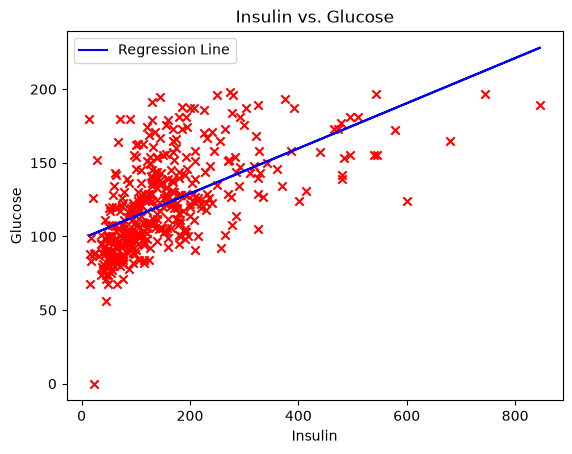

Linear regression for Insulin vs. Glucose:
Linear model: y = 0.1533 * Insulin + 98.4563

Cost function analysis:
Cost (MSE/2): 326.2375
Predictions will be in the range +- 25.54 units.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def load_data(file_path):
    df = pd.read_csv(file_path)
    df = df[df["Insulin"] > 0] # remove zeros
    insulin = df["Insulin"].values
    glucose = df["Glucose"].values
    return insulin, glucose

def visualize(insulin, glucose, slope, intercept):
    plt.scatter(insulin, glucose, marker='x', c='r')
    plt.plot(insulin, predict(insulin, slope, intercept), c='b', label="Regression Line")
    plt.title("Insulin vs. Glucose")
    plt.ylabel('Glucose')
    plt.xlabel('Insulin')
    plt.legend()
    plt.show()

def linear_regression(x, y):
    m = len(x)
    numerator = 0
    denominator = 0

    for i in range(m):
        numerator += (x[i] - np.mean(x)) * (y[i] - np.mean(y))
    for i in range(m):
        denominator += (x[i] - np.mean(x)) ** 2

    slope = numerator / denominator
    intercept = np.mean(y) - slope * np.mean(x)
    return slope, intercept

def predict(x, slope, intercept):
    return slope * x + intercept

def sum_squared_errors(y, prediction):
    m = len(y)
    sse = 0
    for i in range(m):
        sse += (y[i] - prediction[i]) ** 2
    return sse

def cost_function(y, prediction):
    m = len(y)
    cost = sum_squared_errors(y, prediction) / (2 * m)
    return cost

def main():
    insulin, glucose = load_data("diabetes.csv")

    print("Visualization of Insulin vs. Glucose:\n")
    slope, intercept = linear_regression(insulin, glucose)
    prediction = predict(insulin, slope, intercept)
    visualize(insulin, glucose, slope, intercept)

    print("Linear regression for Insulin vs. Glucose:")
    print(f"Linear model: y = {slope:.4f} * Insulin + {intercept:.4f}")

    print("\nCost function analysis:")
    cost = cost_function(glucose, prediction)
    print(f"Cost (MSE/2): {cost:.4f}")

    print(f"Predictions will be in the range +- {(np.sqrt(cost * 2)):.2f} units.")

    #print("Manual prediction:")
    #test_insulin = 150
    #print(f"For Insulin = {test_insulin}: Predicted Glucose = {predict(test_insulin, slope, intercept):.2f}")

if __name__ == "__main__":
    main()

## With Optimization

Final w: 0.5390682160060877, Final b: 3.5568709706454005

Cost function analysis:
Cost (MSE/2): 1982.0985
Predictions will be in the range +- 62.96 units.


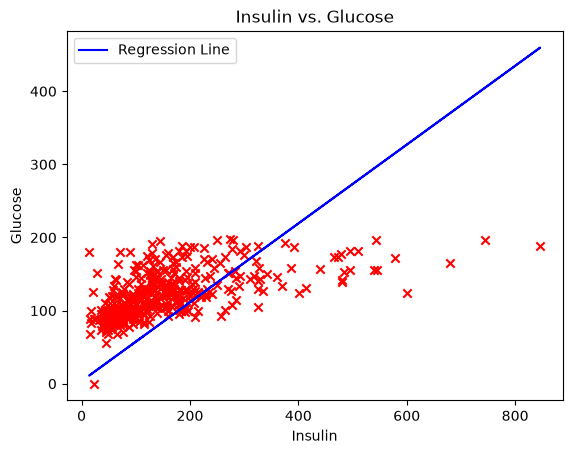

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy

def load_data(file_path):
    df = pd.read_csv(file_path)
    df = df[df["Insulin"] > 0]
    insulin = df["Insulin"].values
    glucose = df["Glucose"].values
    #print(insulin)
    return insulin, glucose

def visualize(insulin, glucose, slope, intercept):
    plt.scatter(insulin, glucose, marker='x', c='r')
    plt.plot(insulin, predict(insulin, slope, intercept), c='b', label="Regression Line")
    plt.title("Insulin vs. Glucose")
    plt.ylabel('Glucose')
    plt.xlabel('Insulin')
    plt.legend()
    plt.show()

def linear_regression(x, y):
    m = len(x)
    numerator = 0
    denominator = 0

    for i in range(m):
        numerator += (x[i] - np.mean(x)) * (y[i] - np.mean(y))
    for i in range(m):
        denominator += (x[i] - np.mean(x)) ** 2

    slope = numerator / denominator
    intercept = np.mean(y) - slope * np.mean(x)
    return slope, intercept

def predict(x, slope, intercept):
    return slope * x + intercept

def sum_squared_errors(y, prediction):
    m = len(y)
    sse = 0
    for i in range(m):
        sse += (y[i] - prediction[i]) ** 2
    return sse

def cost_function(y, prediction):
    m = len(y)
    cost = sum_squared_errors(y, prediction) / (2 * m)
    return cost

def compute_cost(x, y, w, b):
    m = len(x)
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum += cost
    total_cost = (1/(2*m)) * cost_sum
    return total_cost

def compute_gradient(x, y, w, b):
    m = len(x)
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_db += (f_wb - y[i])
        dj_dw += ((f_wb - y[i]) * x[i])
    dj_db /= m
    dj_dw /= m
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, learning_rate_alpha=1e-5, n_iterations=10000):
    w = copy.deepcopy(w_in)
    b = b_in
    cost_history = []

    for i in range(n_iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w -= learning_rate_alpha * dj_dw
        b -= learning_rate_alpha * dj_db
        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

def main():
    insulin, glucose = load_data("diabetes.csv")

    w_final, b_final, cost_history = gradient_descent(insulin, glucose, 0, 0)
    prediction = predict(insulin, w_final, b_final)

    #print("Manual prediction:")
    #test_insulin = 150
    #print(f"For Insulin = {test_insulin}: Predicted Glucose = {predict(test_insulin, slope, intercept):.2f}")

    print(f"Final w: {w_final}, Final b: {b_final}")

    print("\nCost function analysis:")
    cost = cost_function(glucose, prediction)
    print(f"Cost (MSE/2): {cost:.4f}")

    print(f"Predictions will be in the range +- {(np.sqrt(cost * 2)):.2f} units.")

    visualize(insulin, glucose, w_final, b_final)

    '''
    plt.plot(cost_history)
    plt.title("Cost vs. Iterations")
    plt.ylabel('Cost')
    plt.xlabel('Iteration')
    plt.show()
    '''

if __name__ == "__main__":
    main()